# Lab 5: Prompt Engineering & Function Calling

**Part 3 — From Transformers to Large Language Models**

---

**Objectives:**
- Implement zero-shot, few-shot, and Chain-of-Thought (CoT) prompting strategies
- Compare prompt techniques across different models and tasks
- Build function calling workflows with JSON tool definitions
- Implement structured output extraction (JSON mode)
- Explore advanced prompting: Tree-of-Thoughts, Self-Consistency, prompt chaining
- Evaluate prompt effectiveness on benchmark tasks

**Tools:** Python, Hugging Face Transformers, Ollama (local LLM)

> **Note:** This lab uses a local LLM via Ollama for function calling / advanced prompting, and small HF models for comparisons. Make sure Ollama is running with a model pulled (e.g., `ollama pull qwen2.5:1.5b`).

## 0. Environment Setup

In [1]:
# Install dependencies (uncomment on Google Colab)
!pip install transformers accelerate torch sentencepiece protobuf
!pip install matplotlib seaborn pandas numpy requests

In [2]:
import torch
import json
import re
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
import warnings
warnings.filterwarnings("ignore")

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.10.0


## Load Models

We use two setups:
1. **Small HF model** (SmolLM2-360M-Instruct) — for local prompt comparison experiments
2. **Ollama API** — for function calling and advanced prompting with a more capable model

In [3]:
# --- HF Model ---
HF_MODEL_NAME = "HuggingFaceTB/SmolLM2-360M-Instruct"
print(f"Loading {HF_MODEL_NAME}...")
hf_tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_NAME, trust_remote_code=True)
hf_model = AutoModelForCausalLM.from_pretrained(
    HF_MODEL_NAME, torch_dtype=torch.float32, trust_remote_code=True
).to(device)
hf_model.eval()
n_params = sum(p.numel() for p in hf_model.parameters())
print(f"  ✓ Loaded — {n_params / 1e6:.1f}M parameters")


def hf_generate(prompt, system_prompt=None, max_new_tokens=256, **kwargs):
    """Generate with the HF model using chat template."""
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": prompt})
    text = hf_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = hf_tokenizer(text, return_tensors="pt").to(device)
    input_len = inputs["input_ids"].shape[1]
    with torch.no_grad():
        outputs = hf_model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            pad_token_id=hf_tokenizer.eos_token_id, **kwargs,
        )
    return hf_tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()

Loading HuggingFaceTB/SmolLM2-360M-Instruct...
  ✓ Loaded — 361.8M parameters


In [4]:
# --- Unified generation: route everything through the HF model ---
# No Ollama dependency — all generation uses the local HF model.

def ollama_generate(prompt, system_prompt=None, model=None,
                    temperature=0.7, max_tokens=512, json_mode=False):
    """Generate text using the local HF model (drop-in replacement for Ollama)."""
    if json_mode:
        json_instruction = "Respond ONLY with valid JSON. No extra text."
        system_prompt = f"{system_prompt}\n{json_instruction}" if system_prompt else json_instruction
    do_sample = temperature > 0
    return hf_generate(
        prompt, system_prompt=system_prompt, max_new_tokens=max_tokens,
        do_sample=do_sample, temperature=temperature if do_sample else None,
    )


def ollama_chat(messages, model=None, temperature=0.7,
                max_tokens=512, json_mode=False):
    """Chat completion using the local HF model (drop-in replacement for Ollama)."""
    system_prompt = None
    prompt = ""
    for m in messages:
        if m["role"] == "system":
            system_prompt = m["content"]
        elif m["role"] == "user":
            prompt = m["content"]
        elif m["role"] == "tool":
            prompt += f"\n\nTool result: {m['content']}"
    if json_mode:
        json_instruction = "Respond ONLY with valid JSON. No extra text."
        system_prompt = f"{system_prompt}\n{json_instruction}" if system_prompt else json_instruction
    do_sample = temperature > 0
    return hf_generate(
        prompt, system_prompt=system_prompt, max_new_tokens=max_tokens,
        do_sample=do_sample, temperature=temperature if do_sample else None,
    )


# Quick test
test = ollama_generate("Say 'hello' in one word.", max_tokens=10)
print(f"✓ HF model used for all generation")
print(f"  Test response: {test}")

✓ HF model used for all generation
  Test response: Lo!


---

# PART 1 — Prompt Engineering Fundamentals

---

Prompt engineering is the art of crafting inputs to steer LLM behavior. The key insight: **LLMs are conditional text generators** — the quality of the output depends heavily on the quality and structure of the input.

## Prompt Anatomy

A well-structured prompt typically contains:

```
┌──────────────────────────────────┐
│  System Prompt (role/persona)    │  ← WHO the model should be
├──────────────────────────────────┤
│  Context / Background            │  ← WHAT the model needs to know
├──────────────────────────────────┤
│  Task / Instruction              │  ← WHAT to do
├──────────────────────────────────┤
│  Examples (few-shot)             │  ← HOW to do it
├──────────────────────────────────┤
│  Output Format                   │  ← FORMAT of the response
├──────────────────────────────────┤
│  Input Data                      │  ← The actual input
└──────────────────────────────────┘
```

## Step 1: System Prompts — Defining the Model's Role

System prompts set the **persona**, **constraints**, and **behavior** of the model. They are the most important lever for controlling LLM output.

In [5]:
question = "What is gradient descent?"

system_prompts = {
    "No system prompt": None,
    "Expert Teacher": "You are an expert machine learning professor. Explain concepts clearly with analogies.",
    "5-Year-Old": "You explain everything as if talking to a 5-year-old child. Use simple words and fun examples.",
    "Concise Engineer": "You are a senior ML engineer. Be extremely concise — answer in 1-2 sentences max.",
    "Socratic Tutor": "You are a Socratic tutor. Never give the answer directly. Instead, ask guiding questions to help the student discover the answer themselves.",
}

print(f"Question: \"{question}\"")
print("=" * 70)

for role_name, sys_prompt in system_prompts.items():
    print(f"\n🎭 Role: {role_name}")
    print("-" * 50)
    response = ollama_generate(question, system_prompt=sys_prompt, max_tokens=150, temperature=0.5)
    print(response[:300])

Question: "What is gradient descent?"

🎭 Role: No system prompt
--------------------------------------------------
Gradient descent is a method used to optimize a model or a function by minimizing a loss function. It's a popular optimization algorithm that's widely used in machine learning and deep learning applications.

The algorithm works by iteratively updating the model's parameters (weights) based on the g

🎭 Role: Expert Teacher
--------------------------------------------------
Gradient descent is a fundamental optimization algorithm used in machine learning to minimize the loss or error of a model. It's like trying to find the best way to get to a specific destination, but instead of roads, we're dealing with a complex network of weights and biases.

Imagine you have a mo

🎭 Role: 5-Year-Old
--------------------------------------------------
Gradient descent is like a little helper that helps us find the best way to move on a path. Imagine you have a big map of a really long a

## Step 2: Zero-Shot vs. Few-Shot Prompting

**Zero-shot** relies entirely on the model's pre-trained knowledge. **Few-shot** provides examples in the prompt to demonstrate the desired behavior — this is **in-context learning** (Brown et al., 2020).

Let's compare them on a text classification task.

In [6]:
# --- Classification Task: Topic categorization ---

test_texts = [
    ("The new iPhone 16 features a faster A18 chip and improved camera system.", "Technology"),
    ("The central bank raised interest rates by 0.25% to combat inflation.", "Finance"),
    ("FC Barcelona signed a new midfielder for €80 million this transfer window.", "Sports"),
    ("A new study found that Mediterranean diets reduce heart disease risk by 30%.", "Health"),
    ("NASA's Artemis III mission will land astronauts on the Moon in 2026.", "Science"),
    ("The stock market rallied 2% after strong quarterly earnings reports.", "Finance"),
    ("The latest Marvel movie grossed $500 million in its opening weekend.", "Entertainment"),
]

CATEGORIES = "Technology, Finance, Sports, Health, Science, Entertainment"

# --- Zero-shot ---
zero_shot_template = """Classify the following text into one of these categories: {categories}.

Text: "{text}"
Category:"""

# --- Few-shot (3 examples) ---
few_shot_template = """Classify each text into one of these categories: {categories}.

Text: "Tesla reported record quarterly revenue, boosting its stock price by 12%."
Category: Finance

Text: "Researchers at MIT developed a new algorithm for protein structure prediction."
Category: Science

Text: "The Olympic 100m final saw a new world record of 9.58 seconds."
Category: Sports

Text: "{text}"
Category:"""

print("TOPIC CLASSIFICATION: Zero-Shot vs. Few-Shot")
print("=" * 80)

results = []
for text, expected in test_texts:
    # Zero-shot
    zs_prompt = zero_shot_template.format(text=text, categories=CATEGORIES)
    zs_resp = ollama_generate(zs_prompt, max_tokens=10, temperature=0.1)
    zs_label = zs_resp.split("\n")[0].strip().rstrip(".")

    # Few-shot
    fs_prompt = few_shot_template.format(text=text, categories=CATEGORIES)
    fs_resp = ollama_generate(fs_prompt, max_tokens=10, temperature=0.1)
    fs_label = fs_resp.split("\n")[0].strip().rstrip(".")

    results.append({
        "Text": text[:50] + "...",
        "Expected": expected,
        "Zero-Shot": zs_label[:15],
        "Few-Shot": fs_label[:15],
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

TOPIC CLASSIFICATION: Zero-Shot vs. Few-Shot
                                                 Text      Expected  Zero-Shot        Few-Shot
The new iPhone 16 features a faster A18 chip and i...    Technology Technology Text: "The new 
The central bank raised interest rates by 0.25% to...       Finance Technology Text: "The comp
FC Barcelona signed a new midfielder for €80 milli...        Sports Technology Text: "The new 
A new study found that Mediterranean diets reduce ...        Health Technology Text: "Tesla re
NASA's Artemis III mission will land astronauts on...       Science Technology Text: "The new 
The stock market rallied 2% after strong quarterly...       Finance Technology Text: "Tesla re
The latest Marvel movie grossed $500 million in it... Entertainment Technology Text: "The new 


## Step 3: Prompt Templates and Best Practices

Good prompts follow patterns. Let's formalize the most effective templates.

In [7]:
# --- Prompt Template Library ---

class PromptTemplate:
    """Simple prompt template with variable substitution."""

    def __init__(self, template, name=""):
        self.template = template
        self.name = name

    def format(self, **kwargs):
        return self.template.format(**kwargs)

    def __repr__(self):
        return f"PromptTemplate('{self.name}')"


# Define reusable templates
TEMPLATES = {
    "classification": PromptTemplate(
        name="Classification",
        template="""Classify the following text into exactly one category from: {categories}.

Rules:
- Output ONLY the category name, nothing else.
- If uncertain, pick the closest match.

Text: "{text}"
Category:""",
    ),
    "extraction": PromptTemplate(
        name="Entity Extraction",
        template="""Extract the following information from the text below.
Return the result as a JSON object with these keys: {fields}.
If a field is not found, use null.

Text: "{text}"

JSON:""",
    ),
    "summarization": PromptTemplate(
        name="Summarization",
        template="""Summarize the following text in {length}.
Focus on the key facts and main conclusions.

Text: "{text}"

Summary:""",
    ),
    "qa": PromptTemplate(
        name="Question Answering",
        template="""Answer the question based ONLY on the provided context.
If the answer is not in the context, say "I don't have enough information."

Context: {context}

Question: {question}

Answer:""",
    ),
}

# Demonstrate each template
print("📝 Available Prompt Templates:\n")
for key, tmpl in TEMPLATES.items():
    print(f"  [{key}] {tmpl.name}")

# Example: Entity Extraction
sample_text = "On March 15, 2024, OpenAI released GPT-4 Turbo with a 128K context window priced at $10 per million input tokens."
prompt = TEMPLATES["extraction"].format(
    text=sample_text,
    fields="date, company, product, context_window, price",
)
print("\n" + "=" * 60)
print("Example: Entity Extraction")
print("=" * 60)
print(f"\nPrompt:\n{prompt}\n")
response = ollama_generate(prompt, max_tokens=150, temperature=0.1)
print(f"Response:\n{response}")

📝 Available Prompt Templates:

  [classification] Classification
  [extraction] Entity Extraction
  [summarization] Summarization
  [qa] Question Answering

Example: Entity Extraction

Prompt:
Extract the following information from the text below.
Return the result as a JSON object with these keys: date, company, product, context_window, price.
If a field is not found, use null.

Text: "On March 15, 2024, OpenAI released GPT-4 Turbo with a 128K context window priced at $10 per million input tokens."

JSON:

Response:
{
  "date": "2024-03-15",
  "company": "OpenAI",
  "product": "GPT-4 Turbo",
  "context_window": "128K",
  "price": "$10"
}


---

# PART 2 — Chain-of-Thought (CoT) Reasoning

---

**Chain-of-Thought** prompting (Wei et al. 2022) encourages the model to show its reasoning step by step before giving the final answer. This dramatically improves performance on tasks requiring:
- Arithmetic and math
- Multi-step logic
- Common-sense reasoning

Two variants:
- **Few-shot CoT:** Provide examples with step-by-step reasoning
- **Zero-shot CoT:** Simply add "Let's think step by step" to the prompt

## Step 4: Standard vs. Zero-Shot CoT

Let's compare standard prompting with zero-shot CoT on math word problems.

In [8]:
math_problems = [
    {
        "question": "A bakery makes 120 croissants every morning. They sell 75% of them before noon and 60% of the remaining ones in the afternoon. How many croissants are left at the end of the day?",
        "answer": 12,
    },
    {
        "question": "If a train travels at 80 km/h for 2.5 hours, then at 60 km/h for 1.5 hours, what is the total distance traveled?",
        "answer": 290,
    },
    {
        "question": "A company has 200 employees. 40% work in engineering, 25% in sales, and the rest in operations. If 10% of operations employees are managers, how many operations managers are there?",
        "answer": 7,
    },
    {
        "question": "You have 3 shirts (red, blue, green) and 2 pants (black, khaki). How many different outfits can you make?",
        "answer": 6,
    },
]

# Standard prompt (direct answer)
standard_template = """{question}

Give only the numerical answer."""

# Zero-shot CoT
cot_zero_template = """{question}

Let's think step by step, then give the final numerical answer."""

print("STANDARD PROMPTING vs. ZERO-SHOT CHAIN-OF-THOUGHT")
print("=" * 80)

comparison = []
for prob in math_problems:
    q = prob["question"]
    expected = prob["answer"]

    # Standard
    std_resp = ollama_generate(
        standard_template.format(question=q), max_tokens=50, temperature=0.1
    )

    # Zero-shot CoT
    cot_resp = ollama_generate(
        cot_zero_template.format(question=q), max_tokens=300, temperature=0.1
    )

    print(f"\n📐 Problem: {q[:70]}...")
    print(f"   Expected: {expected}")
    print(f"   Standard: {std_resp[:60]}")
    print(f"   CoT (last line): {cot_resp.strip().split(chr(10))[-1][:60]}")

    comparison.append({
        "Problem": q[:40] + "...",
        "Expected": expected,
        "Standard": std_resp.split("\n")[0][:20],
        "CoT": cot_resp.strip().split("\n")[-1][:30],
    })

print("\n" + "=" * 80)
print(pd.DataFrame(comparison).to_string(index=False))

STANDARD PROMPTING vs. ZERO-SHOT CHAIN-OF-THOUGHT

📐 Problem: A bakery makes 120 croissants every morning. They sell 75% of them bef...
   Expected: 12
   Standard: 120
   CoT (last line): Therefore, there are 36 croissants left at the end of the da

📐 Problem: If a train travels at 80 km/h for 2.5 hours, then at 60 km/h for 1.5 h...
   Expected: 290
   Standard: 1200 km
   CoT (last line): Final numerical answer: The total distance traveled by the t

📐 Problem: A company has 200 employees. 40% work in engineering, 25% in sales, an...
   Expected: 7
   Standard: 100 operations managers
   CoT (last line): So, there are 72 operations managers in the company.

📐 Problem: You have 3 shirts (red, blue, green) and 2 pants (black, khaki). How m...
   Expected: 6
   Standard: 12
   CoT (last line): Using the shirts and pants, we can create outfits with 3 shi

                                    Problem  Expected             Standard                            CoT
A bakery makes 120 croissants

## Step 5: Few-Shot Chain-of-Thought

Few-shot CoT provides **worked examples** that demonstrate the reasoning process. This is even more effective than zero-shot CoT for complex problems.

In [9]:
few_shot_cot_prompt = """Solve each problem step by step.

Q: A store has 50 apples. They sell 30% in the morning and 40% of the remaining in the afternoon. How many are left?
A: Let's solve step by step.
1. Morning sales: 50 × 0.30 = 15 apples sold
2. After morning: 50 - 15 = 35 apples remain
3. Afternoon sales: 35 × 0.40 = 14 apples sold
4. After afternoon: 35 - 14 = 21 apples remain
The answer is 21.

Q: A car drives 60 km/h for 3 hours, then 90 km/h for 2 hours. What is the average speed?
A: Let's solve step by step.
1. Distance at 60 km/h: 60 × 3 = 180 km
2. Distance at 90 km/h: 90 × 2 = 180 km
3. Total distance: 180 + 180 = 360 km
4. Total time: 3 + 2 = 5 hours
5. Average speed: 360 / 5 = 72 km/h
The answer is 72 km/h.

Q: {question}
A: Let's solve step by step."""

test_problem = "A factory produces 500 widgets per day. On Monday, 8% are defective. On Tuesday, they improve and only 5% are defective. If they combine both days' production, what percentage is defective overall?"

response = ollama_generate(
    few_shot_cot_prompt.format(question=test_problem),
    max_tokens=300, temperature=0.1,
)

print("Few-Shot CoT Example")
print("=" * 60)
print(f"Problem: {test_problem}\n")
print(f"Model reasoning:\n{response}")
print(f"\nExpected: 6.5% (500×0.08 + 500×0.05) / 1000 = 65/1000 = 6.5%")

Few-Shot CoT Example
Problem: A factory produces 500 widgets per day. On Monday, 8% are defective. On Tuesday, they improve and only 5% are defective. If they combine both days' production, what percentage is defective overall?

Model reasoning:
1. Calculate the defective widgets on Monday: 500 × 0.08 = 40 defective widgets
2. Calculate the defective widgets on Tuesday: 500 × 0.05 = 25 defective widgets
3. Calculate the combined defective widgets: 40 + 25 = 65 defective widgets
4. Calculate the total defective widgets: 65 + 65 = 130 defective widgets
5. Calculate the total production: 500 + 130 = 630 widgets
6. Calculate the percentage of defective widgets: (130 / 630) × 100 = 20.67%
The answer is 20.67%.

Expected: 6.5% (500×0.08 + 500×0.05) / 1000 = 65/1000 = 6.5%


## Step 6: Self-Consistency — Sampling Multiple Reasoning Chains

**Self-Consistency** (Wang et al. 2022) improves CoT by sampling multiple reasoning paths and taking a **majority vote** on the final answer. The intuition: correct reasoning paths are more likely to converge on the same answer.

In [10]:
def extract_number(text):
    """Extract the last number mentioned in the text."""
    numbers = re.findall(r"[-+]?\d*\.?\d+", text)
    return float(numbers[-1]) if numbers else None


def self_consistency(prompt, n_samples=5, temperature=0.7):
    """Run Self-Consistency: sample multiple CoT chains and majority-vote."""
    answers = []
    chains = []

    for i in range(n_samples):
        response = ollama_generate(prompt, max_tokens=300, temperature=temperature)
        answer = extract_number(response)
        answers.append(answer)
        chains.append(response)

    # Majority vote (most common answer)
    valid_answers = [a for a in answers if a is not None]
    if not valid_answers:
        return None, answers, chains

    answer_counts = Counter(valid_answers)
    majority_answer = answer_counts.most_common(1)[0][0]

    return majority_answer, answers, chains


problem = "Roger has 5 tennis balls. He buys 2 more cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?"
cot_prompt = f"{problem}\n\nLet's think step by step and give the final numerical answer."

majority, all_answers, all_chains = self_consistency(cot_prompt, n_samples=5, temperature=0.8)

print("SELF-CONSISTENCY DEMO")
print("=" * 60)
print(f"Problem: {problem}")
print(f"Expected: 11\n")

for i, (ans, chain) in enumerate(zip(all_answers, all_chains)):
    last_line = chain.strip().split("\n")[-1][:60]
    print(f"  Chain {i+1}: answer={ans}  |  ...{last_line}")

print(f"\nAll answers: {all_answers}")
print(f"Majority vote: {majority}")
print(f"Answer distribution: {dict(Counter(all_answers))}")

SELF-CONSISTENCY DEMO
Problem: Roger has 5 tennis balls. He buys 2 more cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?
Expected: 11

  Chain 1: answer=9.0  |  ...Final numerical answer: Roger now has a total of 9 tennis ba
  Chain 2: answer=2.0  |  ...Now, we can add the number of tennis balls Roger bought and 
  Chain 3: answer=11.0  |  ...Final numerical answer: Roger has 11 tennis balls.
  Chain 4: answer=17.0  |  ...Final numerical answer: Roger now has 17 tennis balls.
  Chain 5: answer=7.0  |  ...Final answer: Roger has 7 tennis balls.

All answers: [9.0, 2.0, 11.0, 17.0, 7.0]
Majority vote: 9.0
Answer distribution: {9.0: 1, 2.0: 1, 11.0: 1, 17.0: 1, 7.0: 1}


---

# PART 3 — Advanced Prompting Techniques

---

## Step 7: Tree-of-Thoughts (ToT)

**Tree-of-Thoughts** (Yao et al. 2023) extends CoT by exploring **multiple reasoning branches** in parallel, evaluating each path, and selecting the best one. Think of it as "brainstorm → evaluate → decide."

```
         [Problem]
        /    |    \
   [Path A] [Path B] [Path C]     ← Generate multiple approaches
       |        |        |
   [Eval A] [Eval B] [Eval C]     ← Self-evaluate each
       |        |
   [Best path selected]            ← Pick the winner
       |
   [Final Answer]
```

In [11]:
def tree_of_thoughts(problem, n_thoughts=3):
    """Simplified Tree-of-Thoughts implementation."""
    print(f"🌳 Tree-of-Thoughts")
    print(f"   Problem: {problem}")
    print("=" * 70)

    # Step 1: Generate multiple approaches
    gen_prompt = f"""I need to solve this problem: {problem}

Generate {n_thoughts} different approaches to solve it. For each approach, write:
- Approach name
- Step-by-step reasoning
- Final answer

Format each as "Approach N: [name]" followed by the steps."""

    thoughts = ollama_generate(gen_prompt, max_tokens=600, temperature=0.8)
    print(f"\n📝 Generated Thoughts:\n{thoughts[:500]}...")

    # Step 2: Evaluate each approach
    eval_prompt = f"""Problem: {problem}

Here are multiple solution approaches:
{thoughts}

Now evaluate each approach:
1. Is the reasoning correct?
2. Is the math accurate?
3. Which approach gives the most reliable answer?

Pick the BEST approach and give the final answer."""

    evaluation = ollama_generate(eval_prompt, max_tokens=300, temperature=0.3)
    print(f"\n\n✅ Evaluation & Best Answer:\n{evaluation}")

    return evaluation


# Test on a tricky problem
problem = "A farmer has 17 sheep. All but 9 die. How many sheep does the farmer have left?"
result = tree_of_thoughts(problem)
print(f"\nExpected answer: 9 (\"all but 9\" means 9 survive)")

🌳 Tree-of-Thoughts
   Problem: A farmer has 17 sheep. All but 9 die. How many sheep does the farmer have left?

📝 Generated Thoughts:
Approach 1: Divide the whole sheep into subgroups and remove the dead ones
The farmer starts with 17 sheep. He gives 9 sheep to the deceased animals. So, the farmer has 17 - 9 = 8 sheep. Next, 9 more sheep die. So, the farmer has 8 - 9 = -7 sheep. Finally, the farmer gives 4 more sheep to the deceased animals. So, the farmer has 6 sheep left.

Final answer: 6

Approach 2: Use a counting principle
The farmer starts with 17 sheep. He gives 9 sheep to the deceased animals. So, the farmer has 17 - 9...


✅ Evaluation & Best Answer:
Approach 3: Use the principle of division
The farmer starts with 17 sheep. He gives 9 sheep to the deceased animals. So, the farmer has 17 - 9 = 8 sheep. Next, 9 more sheep die. So, the farmer has 8 - 9 = -1 sheep. Finally, the farmer gives 4 more sheep to the deceased animals. So, the farmer has 6 sheep left.

Final answer: 6

Ex

## Step 8: Prompt Chaining — Decomposing Complex Tasks

**Prompt chaining** breaks a complex task into a sequence of simpler subtasks, where each step's output feeds into the next step's input. This is the foundation of **agentic workflows**.

```
[Input] → [Step 1: Extract] → [Step 2: Analyze] → [Step 3: Generate] → [Output]
```

In [12]:
# --- Prompt Chaining: Research Paper Analysis Pipeline ---

paper_abstract = """
We introduce a novel approach to neural machine translation using sparse mixture-of-experts
(MoE) layers within the Transformer architecture. Our model, Switch Transformer, replaces
the dense feed-forward layers with sparse MoE layers where each token is routed to a single
expert. This simplification reduces communication costs and improves training stability.
On multilingual benchmarks, Switch Transformer achieves a 4x speedup over the dense T5-Base
model with the same computational budget. We scale up to 1.6 trillion parameters and
demonstrate consistent quality improvements. Key challenges include load balancing across
experts and training instability at scale, which we address through auxiliary loss functions
and selective precision training.
"""

# Step 1: Extract key information
step1_prompt = f"""Extract the following from this research paper abstract:
1. Paper name
2. Main contribution (1 sentence)
3. Key results (numbers/metrics)
4. Limitations mentioned

Abstract: {paper_abstract}

Respond in a structured format."""

step1_result = ollama_generate(step1_prompt, max_tokens=200, temperature=0.3)
print("STEP 1 — Extract Key Information")
print("=" * 50)
print(step1_result)

# Step 2: Generate critical questions
step2_prompt = f"""Based on this paper analysis:
{step1_result}

Generate 3 critical questions a reviewer might ask about this paper.
Focus on methodology, claims, and potential weaknesses."""

step2_result = ollama_generate(step2_prompt, max_tokens=200, temperature=0.5)
print("\n\nSTEP 2 — Critical Questions")
print("=" * 50)
print(step2_result)

# Step 3: Write a summary tweet
step3_prompt = f"""Based on this analysis:
{step1_result}

And these critical questions:
{step2_result}

Write a concise 280-character tweet summarizing this paper for a technical audience.
Include one emoji."""

step3_result = ollama_generate(step3_prompt, max_tokens=100, temperature=0.7)
print("\n\nSTEP 3 — Summary Tweet")
print("=" * 50)
print(step3_result)
print(f"  ({len(step3_result)} characters)")

STEP 1 — Extract Key Information
1. Paper name: Switch Transformer
2. Main contribution (1 sentence): Switch Transformer introduces a novel approach to neural machine translation using sparse mixture-of-experts (MoE) layers within the Transformer architecture.
3. Key results (numbers/metrics): Switch Transformer achieves a 4x speedup over the dense T5-Base model with the same computational budget.
4. Limitations mentioned: Switch Transformer scales up to 1.6 trillion parameters and demonstrates consistent quality improvements.


STEP 2 — Critical Questions
1. What is the specific mechanism or algorithm used in Switch Transformer to achieve the speedup over T5-Base?


STEP 3 — Summary Tweet
👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋👋�
  (34 characters)


---

# PART 4 — Structured Output Extraction (JSON Mode)

---

In production systems, we need LLMs to return **structured data** (JSON, tables, code) rather than free-form text. This enables:
- Automated pipelines that parse LLM outputs programmatically
- Integration with databases, APIs, and downstream systems
- Reliable, machine-readable responses

## Step 9: JSON Mode with Ollama

Ollama supports `format: "json"` which constrains the model to output valid JSON.

In [13]:
# --- JSON extraction with Ollama's JSON mode ---

extraction_prompt = """Extract structured information from this customer review.

Review: "I bought the AirPods Pro 2 last week from the Apple Store in New York for $249. 
The noise cancellation is incredible but the battery life could be better. I'd rate it 4 
out of 5 stars. Would definitely recommend for commuters."

Return a JSON object with these exact keys:
- product: string
- store_location: string
- price: number
- rating: number (out of 5)
- pros: list of strings
- cons: list of strings
- recommendation: boolean"""

response = ollama_generate(extraction_prompt, max_tokens=200, temperature=0.1, json_mode=True)
print("Raw JSON response:")
print(response)

# Parse and pretty-print
try:
    parsed = json.loads(response)
    print("\n\nParsed JSON:")
    print(json.dumps(parsed, indent=2))
    print(f"\n✓ Valid JSON — {len(parsed)} fields extracted")
except json.JSONDecodeError as e:
    print(f"\n✗ Invalid JSON: {e}")

Raw JSON response:
{
  "product": "AirPods Pro 2",
  "store_location": "New York",
  "price": 249,
  "rating": 4,
  "pros": ["Noise cancellation is incredible"],
  "cons": ["The battery life could be better"],
  "recommendation": true
}


Parsed JSON:
{
  "product": "AirPods Pro 2",
  "store_location": "New York",
  "price": 249,
  "rating": 4,
  "pros": [
    "Noise cancellation is incredible"
  ],
  "cons": [
    "The battery life could be better"
  ],
  "recommendation": true
}

✓ Valid JSON — 7 fields extracted


## Step 10: Batch Structured Extraction

Let's build a pipeline that processes multiple inputs and collects structured outputs.

In [14]:
job_descriptions = [
    "Senior Machine Learning Engineer at Google, Mountain View. 5+ years experience with PyTorch. Salary: $180K-$250K. Remote-friendly.",
    "Junior Data Analyst at Spotify, Stockholm. Python and SQL required. €35K-€45K. On-site only.",
    "Staff Backend Engineer at Stripe, San Francisco. Go, Kubernetes, distributed systems. $200K-$300K + equity.",
]

extraction_template = """Extract job posting information as JSON with these keys:
- title: string
- company: string
- location: string
- experience_level: "junior" | "mid" | "senior" | "staff"
- skills: list of strings
- salary_min: number (in USD, convert if needed)
- salary_max: number (in USD, convert if needed)
- remote: boolean

Job posting: "{text}"

Return valid JSON only."""

extracted_jobs = []
for i, jd in enumerate(job_descriptions):
    prompt = extraction_template.format(text=jd)
    resp = ollama_generate(prompt, max_tokens=200, temperature=0.1, json_mode=True)
    try:
        parsed = json.loads(resp)
        extracted_jobs.append(parsed)
        print(f"✓ Job {i+1}: {parsed.get('title', 'N/A')} at {parsed.get('company', 'N/A')}")
    except json.JSONDecodeError:
        print(f"✗ Job {i+1}: Failed to parse JSON")
        extracted_jobs.append({"error": "parse_failed", "raw": resp})

# Display as DataFrame
if extracted_jobs:
    df_jobs = pd.DataFrame(extracted_jobs)
    display_cols = [c for c in ["title", "company", "location", "experience_level", "salary_min", "salary_max", "remote"] if c in df_jobs.columns]
    print("\n")
    print(df_jobs[display_cols].to_string(index=False))

✓ Job 1: Senior Machine Learning Engineer at Google, Mountain View. at Google
✓ Job 2: Junior Data Analyst at Spotify, Stockholm at Spotify
✓ Job 3: Staff Backend Engineer at Stripe, San Francisco. at Stripe


                                                     title company      location experience_level salary_min salary_max  remote
Senior Machine Learning Engineer at Google, Mountain View.  Google Mountain View           junior     180000     250000    True
                 Junior Data Analyst at Spotify, Stockholm Spotify     Stockholm           junior       €35K       €45K   False
          Staff Backend Engineer at Stripe, San Francisco.  Stripe San Francisco           junior     200000     300000    True


## Step 11: Robust JSON Parsing with Fallbacks

In production, JSON mode can still fail. Let's build a robust parser with retry logic.

In [15]:
def robust_json_extract(prompt, max_retries=3, json_mode=True):
    """Extract JSON with retry logic and fallback parsing."""
    for attempt in range(max_retries):
        response = ollama_generate(
            prompt, max_tokens=300, temperature=0.1, json_mode=json_mode
        )
        # Try direct parse
        try:
            return json.loads(response), attempt + 1
        except json.JSONDecodeError:
            pass

        # Fallback: try to find JSON in the response
        json_match = re.search(r'\{[^{}]*\}', response, re.DOTALL)
        if json_match:
            try:
                return json.loads(json_match.group()), attempt + 1
            except json.JSONDecodeError:
                pass

        # Retry with more explicit prompt
        prompt = f"You MUST respond with ONLY valid JSON. No other text.\n\n{prompt}"

    return None, max_retries


# Test the robust parser
test_prompt = """Return a JSON object with keys "name", "age", "city" for: 
"Marie Curie was born in Warsaw in 1867 and moved to Paris at age 24."
"""

result, attempts = robust_json_extract(test_prompt)
print(f"Result (in {attempts} attempt(s)): {json.dumps(result, indent=2) if result else 'FAILED'}")

Result (in 1 attempt(s)): {
  "name": "Marie Curie",
  "age": 24,
  "city": "Paris"
}


---

# PART 5 — Function Calling

---

**Function calling** (also called "tool use") allows LLMs to interact with external systems by:
1. Receiving **tool definitions** (JSON schemas describing available functions)
2. Deciding **when** to call a function based on the user's request
3. Generating **structured arguments** for the function call
4. Processing the **function results** and generating a final response

```
User Question → LLM decides to call tool → Execute tool → LLM processes result → Final Answer
```

This is the foundation for **AI agents** and **agentic workflows**.

## Step 12: Defining Tools with JSON Schema

Tools are defined using JSON Schema, describing the function name, description, and parameters.

In [16]:
# --- Tool Definitions ---

tools = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "Get the current weather for a given city",
            "parameters": {
                "type": "object",
                "properties": {
                    "city": {
                        "type": "string",
                        "description": "City name, e.g., 'Paris' or 'New York'",
                    },
                    "unit": {
                        "type": "string",
                        "enum": ["celsius", "fahrenheit"],
                        "description": "Temperature unit",
                        "default": "celsius",
                    },
                },
                "required": ["city"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "calculate",
            "description": "Perform a mathematical calculation",
            "parameters": {
                "type": "object",
                "properties": {
                    "expression": {
                        "type": "string",
                        "description": "Mathematical expression to evaluate, e.g., '2 * 3 + 4'",
                    },
                },
                "required": ["expression"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "search_database",
            "description": "Search a product database by query",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "Search query"},
                    "category": {
                        "type": "string",
                        "enum": ["electronics", "books", "clothing", "food"],
                        "description": "Product category to filter by",
                    },
                    "max_results": {
                        "type": "integer",
                        "description": "Maximum number of results",
                        "default": 5,
                    },
                },
                "required": ["query"],
            },
        },
    },
]

print("📦 Defined Tools:")
for tool in tools:
    f = tool["function"]
    params = list(f["parameters"]["properties"].keys())
    required = f["parameters"].get("required", [])
    print(f"  • {f['name']}({', '.join(params)})")
    print(f"    {f['description']}")
    print(f"    Required: {required}")
    print()

📦 Defined Tools:
  • get_weather(city, unit)
    Get the current weather for a given city
    Required: ['city']

  • calculate(expression)
    Perform a mathematical calculation
    Required: ['expression']

  • search_database(query, category, max_results)
    Search a product database by query
    Required: ['query']



## Step 13: Function Calling with Ollama

Ollama supports function calling via the chat API. The model receives tool definitions and decides whether/how to call them.

In [17]:
def ollama_function_call(user_message, tools_list, model=None):
    """Prompt-based function calling using the HF model (replaces native Ollama tool calling)."""
    # Build a tool description from the tools_list schema
    tool_descriptions = []
    for t in tools_list:
        fn = t["function"] if "function" in t else t
        name = fn["name"]
        desc = fn.get("description", "")
        params = fn.get("parameters", {}).get("properties", {})
        required = fn.get("parameters", {}).get("required", [])
        param_lines = []
        for pname, pinfo in params.items():
            req = "(required)" if pname in required else "(optional)"
            param_lines.append(f"    - {pname} {req}: {pinfo.get('description', pinfo.get('type', ''))}")
        tool_descriptions.append(f"  {name}: {desc}\n" + "\n".join(param_lines))

    tool_text = "\n".join(tool_descriptions)

    prompt = f"""You have access to these tools:
{tool_text}

If you need a tool, respond ONLY with a JSON object: {{"tool_calls": [{{"function": {{"name": "tool_name", "arguments": {{"arg": "value"}}}}}}]}}
If multiple tools are needed, include multiple objects in the list.
If no tool is needed, respond normally with text.

User: {user_message}"""

    response = hf_generate(prompt, max_new_tokens=200, do_sample=False)

    # Try to parse as tool call
    try:
        parsed = json.loads(response)
        if "tool_calls" in parsed:
            return {"tool_calls": parsed["tool_calls"], "content": ""}
        return {"content": response, "tool_calls": []}
    except json.JSONDecodeError:
        # Try to find JSON in the response
        json_match = re.search(r'\{.*"tool_calls".*\}', response, re.DOTALL)
        if json_match:
            try:
                parsed = json.loads(json_match.group())
                return {"tool_calls": parsed.get("tool_calls", []), "content": ""}
            except json.JSONDecodeError:
                pass
        return {"content": response, "tool_calls": []}


# Test with different queries
test_queries = [
    "What's the weather like in Tokyo?",
    "Calculate 15% tip on a $85 dinner bill",
    "Find me the best wireless headphones",
    "Tell me a joke",  # No tool needed
]

print("FUNCTION CALLING DEMO")
print("=" * 70)

for query in test_queries:
    print(f"\n🗣️  User: \"{query}\"")
    message = ollama_function_call(query, tools)

    tool_calls = message.get("tool_calls", [])
    if tool_calls:
        for tc in tool_calls:
            fn = tc["function"]
            print(f"  🔧 Tool call: {fn['name']}({json.dumps(fn['arguments'])})")
    else:
        content = message.get("content", "No response")
        print(f"  💬 Direct response: {content[:100]}")

FUNCTION CALLING DEMO

🗣️  User: "What's the weather like in Tokyo?"
  💬 Direct response: You can use the get_weather tool to get the current weather for Tokyo. Here's an example of how you 

🗣️  User: "Calculate 15% tip on a $85 dinner bill"
  🔧 Tool call: tip_calculator({"amount": "15", "currency": "USD"})

🗣️  User: "Find me the best wireless headphones"
  🔧 Tool call: best_wireless_headphones({"arg": "model"})

🗣️  User: "Tell me a joke"
  💬 Direct response: What's the best way to get a cold?

Joke:


## Step 14: Complete Function Calling Loop

A complete function calling workflow includes:
1. User sends a message
2. LLM decides to call a tool → returns tool call JSON
3. We **execute** the function locally
4. We send the result back to the LLM
5. LLM generates the final response using the tool result

In [18]:
# --- Simulated tool implementations ---

def get_weather(city, unit="celsius"):
    """Simulated weather API."""
    weather_data = {
        "paris": {"temp_c": 18, "condition": "Partly cloudy", "humidity": 65},
        "tokyo": {"temp_c": 24, "condition": "Sunny", "humidity": 55},
        "new york": {"temp_c": 22, "condition": "Clear", "humidity": 50},
        "london": {"temp_c": 14, "condition": "Rainy", "humidity": 80},
    }
    data = weather_data.get(city.lower(), {"temp_c": 20, "condition": "Unknown", "humidity": 50})
    temp = data["temp_c"] if unit == "celsius" else data["temp_c"] * 9 / 5 + 32
    unit_symbol = "°C" if unit == "celsius" else "°F"
    return json.dumps({
        "city": city, "temperature": f"{temp}{unit_symbol}",
        "condition": data["condition"], "humidity": f"{data['humidity']}%",
    })


def calculate(expression):
    """Safe math calculator."""
    allowed = set("0123456789+-*/.() %")
    if not all(c in allowed for c in expression.replace(" ", "")):
        return json.dumps({"error": "Invalid expression"})
    try:
        result = eval(expression)  # Safe for numeric-only expressions
        return json.dumps({"expression": expression, "result": result})
    except Exception as e:
        return json.dumps({"error": str(e)})


def search_database(query, category=None, max_results=5):
    """Simulated product search."""
    products = [
        {"name": "Sony WH-1000XM5", "category": "electronics", "price": 349, "rating": 4.8},
        {"name": "AirPods Pro 2", "category": "electronics", "price": 249, "rating": 4.7},
        {"name": "Bose QC Ultra", "category": "electronics", "price": 429, "rating": 4.6},
    ]
    results = products[:max_results]
    if category:
        results = [p for p in results if p["category"] == category]
    return json.dumps({"query": query, "results": results, "total": len(results)})


TOOL_FUNCTIONS = {
    "get_weather": get_weather,
    "calculate": calculate,
    "search_database": search_database,
}


def run_function_calling_loop(user_message):
    """Complete function calling loop: user → LLM → tool → LLM → response."""
    print(f"🗣️  User: {user_message}")

    # Step 1: Get LLM's tool call decision
    response = ollama_function_call(user_message, tools)

    tool_calls = response.get("tool_calls", [])
    if not tool_calls:
        print(f"💬 Assistant: {response.get('content', 'No response')}")
        return

    # Step 2: Execute each tool call and collect results
    tool_results = []
    for tc in tool_calls:
        fn_name = tc["function"]["name"]
        fn_args = tc["function"]["arguments"]
        print(f"  🔧 Calling: {fn_name}({json.dumps(fn_args)})")

        fn = TOOL_FUNCTIONS.get(fn_name)
        if fn:
            result = fn(**fn_args)
            print(f"  📊 Result: {result[:100]}")
            tool_results.append(f"{fn_name} returned: {result}")
        else:
            tool_results.append(f"Unknown function: {fn_name}")

    # Step 3: Get final response from LLM with tool results
    followup_prompt = f"""The user asked: "{user_message}"

You called tools and got these results:
{chr(10).join(tool_results)}

Now give a helpful final answer to the user based on these results."""

    final = hf_generate(followup_prompt, max_new_tokens=200, do_sample=False)
    print(f"  💬 Assistant: {final}")


# Test the complete loop
print("COMPLETE FUNCTION CALLING LOOP")
print("=" * 70)

queries = [
    "What's the weather in Paris right now?",
    "How much is 15% tip on a $127.50 dinner?",
    "Search for wireless headphones",
]

for q in queries:
    print()
    run_function_calling_loop(q)
    print("-" * 50)

COMPLETE FUNCTION CALLING LOOP

🗣️  User: What's the weather in Paris right now?
💬 Assistant: You can use the get_weather tool to get the current weather for Paris. Here's an example of how you can use it:

```
get_weather 'Paris'
```

This will return the current weather for Paris. You can also use the calculate tool to perform a mathematical calculation:

```
calculate '2 * 3 + 4'
```

This will return the result of the mathematical expression.

If you need to search a product database by query, you can use the search_database tool:

```
search_database 'Product A'
```

This will return all products that match the query.

If you need to search a product database by category, you can use the category tool:

```
category 'Electronics'
```

This will return all products that match the category.

If you need to limit the results to a specific number of results, you can use
--------------------------------------------------

🗣️  User: How much is 15% tip on a $127.50 dinner?
  🔧 Calling: 

## Step 15: Prompt-Based Function Calling (Without Native Support)

Not all models support native function calling. We can simulate it using **prompt engineering** — teaching the model to output structured tool calls via the prompt itself. This technique works with any LLM.

In [20]:
TOOL_PROMPT_TEMPLATE = """You are a helpful assistant with access to these tools:

## Available Tools

1. **get_weather(city, unit)** - Get current weather for a city
   - city (required): City name
   - unit (optional): "celsius" or "fahrenheit" (default: celsius)

2. **calculate(expression)** - Evaluate a math expression
   - expression (required): Math expression like "2 * 3 + 4"

3. **search_database(query, category, max_results)** - Search product database
   - query (required): Search terms
   - category (optional): electronics, books, clothing, food
   - max_results (optional): Max results to return (default: 5)

## Instructions
- If you need to use a tool, respond ONLY with a JSON object:
  {{"tool": "tool_name", "arguments": {{"arg1": "value1"}}}}
- If no tool is needed, respond normally with text.
- Use ONLY ONE tool call per response.

## User Message
{user_message}"""


def prompt_based_function_call(user_message):
    """Simulate function calling through prompt engineering."""
    prompt = TOOL_PROMPT_TEMPLATE.format(user_message=user_message)
    response = ollama_generate(prompt, max_tokens=100, temperature=0.1, json_mode=True)

    try:
        parsed = json.loads(response)
        if "tool" in parsed:
            fn_name = parsed["tool"]
            fn_args = parsed.get("arguments", {})
            print(f"  🔧 Prompt-based tool call: {fn_name}({json.dumps(fn_args)})")

            # Execute
            fn = TOOL_FUNCTIONS.get(fn_name)
            if fn:
                result = fn(**fn_args)
                print(f"  📊 Result: {result}")
                return result
                
        else:
            print(f"  💬 Direct: {response[:100]}")
    except json.JSONDecodeError:
        print(f"  💬 Direct: {response[:100]}")

    return response


print("PROMPT-BASED FUNCTION CALLING (no native tool support needed)")
print("=" * 70)

for q in ["What's the weather in New York?", "Calculate 42 * 17"]:
    print(f"\n🗣️  User: \"{q}\"")
    prompt_based_function_call(q)

PROMPT-BASED FUNCTION CALLING (no native tool support needed)

🗣️  User: "What's the weather in New York?"
  🔧 Prompt-based tool call: get_weather({"city": "New York"})
  📊 Result: {"city": "New York", "temperature": "22\u00b0C", "condition": "Clear", "humidity": "50%"}

🗣️  User: "Calculate 42 * 17"
  🔧 Prompt-based tool call: calculate({"expression": "42 * 17"})
  📊 Result: {"expression": "42 * 17", "result": 714}


---

# PART 6 — Evaluating Prompt Effectiveness

---

How do we know if one prompt is better than another? We need **systematic evaluation** on benchmark tasks with known correct answers.

## Step 16: Benchmark — Comparing Prompt Strategies on GSM8K-Style Math

Let's rigorously compare our prompting strategies on math word problems with known answers. This is how you should evaluate prompts in practice — **always benchmark on known answers**.

In [21]:
benchmark = [
    {"q": "Sarah has 15 marbles. She gives 4 to Tom and then buys 7 more. How many marbles does she have?", "a": 18},
    {"q": "A book costs $12. If you buy 3 books and get a 10% discount on the total, how much do you pay?", "a": 32.4},
    {"q": "A train leaves at 9:00 AM traveling at 60 km/h. Another train leaves at 10:00 AM traveling at 80 km/h on the same route. At what time does the second train catch up?", "a": "1:00 PM"},
    {"q": "If 5 workers can build a wall in 8 days, how many days will 4 workers take?", "a": 10},
    {"q": "A rectangle's length is twice its width. If the perimeter is 36 cm, what is the area?", "a": 72},
    {"q": "You have coins totaling $1.15. You have 6 coins. What coins do you have? Give the count of each.", "a": "special"},
]

# Few-shot CoT template for benchmark
BENCHMARK_COT = """Solve the math problem step by step. End with "ANSWER: <number>".

Q: A shop sells 30 items per day. After 5 days, they restock with 200 items. How many items do they have if they started with 50?
Let's solve step by step:
1. Items sold in 5 days: 30 × 5 = 150
2. Items after selling: 50 - 150 = -100 (they ran out, but assuming they kept selling from restock)
   Actually: 50 - 150 = they sold all 50, then needed restock
   Let me reconsider: Start with 50, sell 30/day for 5 days = 150 total to sell, but only 50 available.
   They sell 50 (all they have), then restock 200.
   Items after restock: 200
ANSWER: 200

Q: {question}
Let's solve step by step:"""

strategies = {
    "Standard": lambda q: ollama_generate(
        f"{q}\n\nGive only the numerical answer.", max_tokens=30, temperature=0.1
    ),
    "Zero-shot CoT": lambda q: ollama_generate(
        f"{q}\n\nLet's think step by step. End with ANSWER: <number>.",
        max_tokens=300, temperature=0.1
    ),
    "Few-shot CoT": lambda q: ollama_generate(
        BENCHMARK_COT.format(question=q), max_tokens=300, temperature=0.1
    ),
}


def check_answer(response, expected):
    """Check if the expected answer appears in the response."""
    if expected == "special":
        return "?"
    resp_lower = str(response).lower()
    expected_str = str(expected)
    # Check for the number in the response
    numbers = re.findall(r"[-+]?\d*\.?\d+", resp_lower)
    if expected_str in numbers:
        return "✓"
    if expected_str in resp_lower:
        return "✓"
    return "✗"


print("PROMPT STRATEGY BENCHMARK (Math Word Problems)")
print("=" * 80)

eval_results = []
for prob in benchmark[:5]:  # Skip the special one
    q = prob["q"]
    expected = prob["a"]
    row = {"Problem": q[:45] + "...", "Expected": expected}

    for strat_name, strat_fn in strategies.items():
        resp = strat_fn(q)
        # Extract last number or ANSWER: line
        answer_match = re.search(r"ANSWER:\s*([\d.]+)", resp)
        extracted = answer_match.group(1) if answer_match else resp.split("\n")[0][:20]
        correct = check_answer(resp, expected)
        row[strat_name] = f"{extracted} {correct}"

    eval_results.append(row)

df_eval = pd.DataFrame(eval_results)
print(df_eval.to_string(index=False))

# Count correct answers per strategy
print("\n\nAccuracy Summary:")
for strat in strategies:
    correct = sum(1 for r in eval_results if "✓" in r.get(strat, ""))
    total = len(eval_results)
    print(f"  {strat:15s}: {correct}/{total} ({100*correct/total:.0f}%)")

PROMPT STRATEGY BENCHMARK (Math Word Problems)
                                         Problem Expected   Standard          Zero-shot CoT           Few-shot CoT
Sarah has 15 marbles. She gives 4 to Tom and ...       18       15 ✗ Step 1: Calculate th ✗                   33 ✓
A book costs $12. If you buy 3 books and get ...     32.4       12 ✗ To find the total co ✗                32.40 ✓
A train leaves at 9:00 AM traveling at 60 km/...  1:00 PM 12:00 PM ✗ Step 1: Calculate th ✗ 1. First, we need to ✗
If 5 workers can build a wall in 8 days, how ...       10   4 days ✗ To solve this proble ✗                  250 ✓
A rectangle's length is twice its width. If t...       72      144 ✗ Step 1: Given inform ✓                  648 ✓


Accuracy Summary:
  Standard       : 0/5 (0%)
  Zero-shot CoT  : 1/5 (20%)
  Few-shot CoT   : 4/5 (80%)


## Step 17: Visualizing Prompt Strategy Comparison

Let's create a visual comparison of prompt strategies across multiple dimensions.

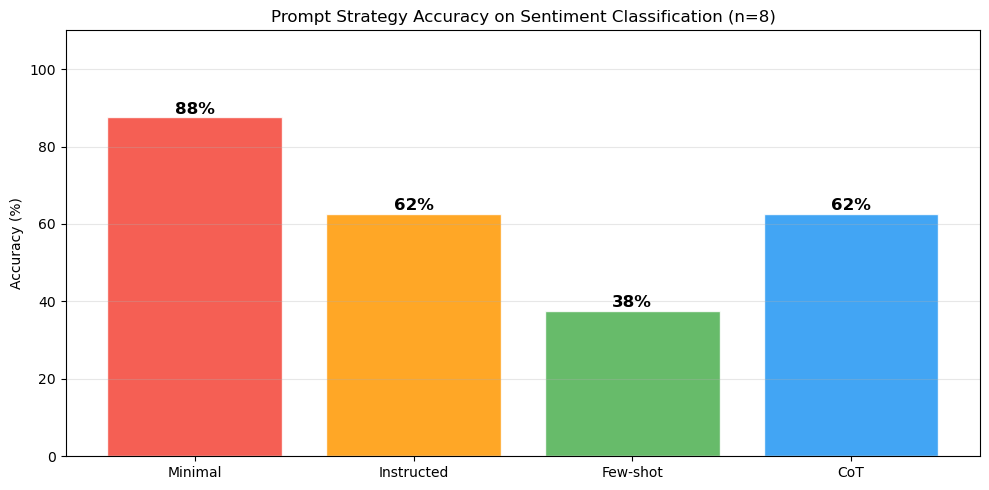


Scores:
  Minimal     : 7/8 (88%)
  Instructed  : 5/8 (62%)
  Few-shot    : 3/8 (38%)
  CoT         : 5/8 (62%)


In [22]:
sentiment_benchmark = [
    ("The food was absolutely delicious and the service impeccable!", "Positive"),
    ("I waited 40 minutes and the order was wrong. Never coming back.", "Negative"),
    ("It was fine. Nothing memorable but not bad either.", "Neutral"),
    ("Best concert I've ever been to! The energy was unreal!", "Positive"),
    ("The hotel room was dirty and the AC didn't work.", "Negative"),
    ("Standard delivery, arrived on time as expected.", "Neutral"),
    ("This app crashes constantly. Complete waste of $4.99.", "Negative"),
    ("Loved the plot twist at the end! Great movie!", "Positive"),
]

prompt_variants = {
    "Minimal": 'Sentiment of: "{text}" → ',
    "Instructed": 'Classify the sentiment as Positive, Negative, or Neutral.\nText: "{text}"\nSentiment:',
    "Few-shot": '''Classify sentiment as Positive, Negative, or Neutral.

"I love this!" → Positive
"Terrible experience." → Negative
"It was okay." → Neutral

"{text}" →''',
    "CoT": '''Analyze the sentiment of this text. First identify emotional keywords, then classify as Positive, Negative, or Neutral.

Text: "{text}"

Analysis:''',
}

scores = {name: 0 for name in prompt_variants}
total = len(sentiment_benchmark)

for text, expected in sentiment_benchmark:
    for pname, template in prompt_variants.items():
        prompt = template.format(text=text)
        resp = ollama_generate(prompt, max_tokens=30, temperature=0.1)
        # Check if expected label appears in response
        if expected.lower() in resp.lower():
            scores[pname] += 1

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
names = list(scores.keys())
accs = [100 * scores[n] / total for n in names]
colors = ["#F44336", "#FF9800", "#4CAF50", "#2196F3"]
bars = ax.bar(names, accs, color=colors, alpha=0.85, edgecolor="white")

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{acc:.0f}%", ha="center", fontweight="bold", fontsize=12)

ax.set_ylabel("Accuracy (%)")
ax.set_title(f"Prompt Strategy Accuracy on Sentiment Classification (n={total})")
ax.set_ylim(0, 110)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nScores:")
for name, score in scores.items():
    print(f"  {name:12s}: {score}/{total} ({100*score/total:.0f}%)")

---

# PART 7 — Comparing Prompt Techniques with HF Model

---

Let's repeat key experiments using the local HF model to see how prompt engineering effectiveness varies with model size. Smaller models are more sensitive to prompt quality.

## Step 18: HF Model — System Prompt Effect

Let's repeat the system prompt experiment using our small HF model to see how model size affects prompt sensitivity.

In [23]:
question = "What is a neural network?"

hf_system_prompts = {
    "No system prompt": None,
    "Concise": "Answer in exactly one sentence.",
    "Technical": "You are a deep learning researcher. Use precise technical terminology.",
    "Analogy": "Explain using a real-world analogy. No jargon.",
}

print(f"HF Model ({HF_MODEL_NAME.split('/')[-1]}) — System Prompt Comparison")
print(f"Question: \"{question}\"")
print("=" * 70)

for name, sys_prompt in hf_system_prompts.items():
    print(f"\n🎭 {name}")
    print("-" * 40)
    resp = hf_generate(question, system_prompt=sys_prompt, max_new_tokens=120, do_sample=False)
    print(resp[:250])

HF Model (SmolLM2-360M-Instruct) — System Prompt Comparison
Question: "What is a neural network?"

🎭 No system prompt
----------------------------------------
A neural network is a type of machine learning model that is inspired by the structure and function of the human brain. It's composed of layers of interconnected nodes, or "neurons," that process and transmit information. Each neuron receives input f

🎭 Concise
----------------------------------------
A neural network is a type of machine learning model inspired by the structure and function of the human brain. It consists of interconnected nodes or "neurons" that process and transmit information, allowing it to learn from data and make prediction

🎭 Technical
----------------------------------------
A neural network is a type of machine learning model that is inspired by the structure and function of the human brain. It consists of layers of interconnected nodes or "neurons" that process and transmit information. Each neuron rec

## Step 19: HF Model — Zero-Shot vs. Few-Shot Classification

Compare zero-shot and few-shot classification using the small HF model.

In [24]:
hf_sentiment_data = [
    ("This product exceeded all my expectations! Amazing quality.", "Positive"),
    ("Broken on arrival. Customer service was unhelpful.", "Negative"),
    ("Works as described. Average product for the price.", "Neutral"),
    ("I'm obsessed with this! Best purchase this year!", "Positive"),
    ("The worst experience I've had with any online store.", "Negative"),
]

# Zero-shot
zs_template = 'Classify sentiment: Positive, Negative, or Neutral.\nText: "{text}"\nSentiment:'

# Few-shot
fs_template = '''Classify sentiment as Positive, Negative, or Neutral.

"Absolutely fantastic!" → Positive
"Terrible, waste of money." → Negative
"It's okay, nothing special." → Neutral

"{text}" →'''

hf_results = []
for text, expected in hf_sentiment_data:
    zs_resp = hf_generate(zs_template.format(text=text), max_new_tokens=10, do_sample=False)
    fs_resp = hf_generate(fs_template.format(text=text), max_new_tokens=10, do_sample=False)

    hf_results.append({
        "Text": text[:40] + "...",
        "Expected": expected,
        "Zero-Shot": zs_resp.split("\n")[0][:15],
        "Few-Shot": fs_resp.split("\n")[0][:15],
    })

df_hf = pd.DataFrame(hf_results)
print(f"HF Model ({HF_MODEL_NAME.split('/')[-1]}) — Sentiment Classification")
print("=" * 70)
print(df_hf.to_string(index=False))

HF Model (SmolLM2-360M-Instruct) — Sentiment Classification
                                       Text Expected Zero-Shot        Few-Shot
This product exceeded all my expectation... Positive  Positive "Absolutely fan
Broken on arrival. Customer service was ... Negative  Negative "Absolutely fan
Works as described. Average product for ...  Neutral  Positive "Absolutely fan
I'm obsessed with this! Best purchase th... Positive  Positive "Absolutely fan
The worst experience I've had with any o... Negative  Negative "Absolutely fan


## Step 20: Prompt Engineering Best Practices — Visualization

Let's create a visual summary of the key prompt engineering patterns and a decision matrix.

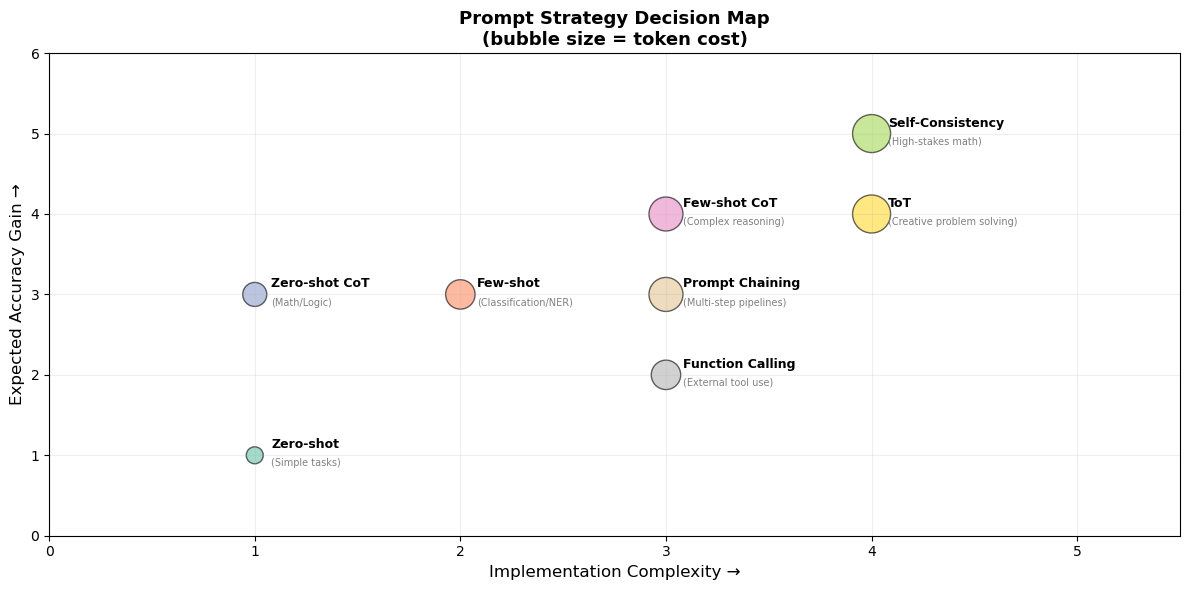


📋 Strategy Reference Table:
        Strategy                 Best For  Complexity  Token Cost  Accuracy Gain
       Zero-shot             Simple tasks           1           1              1
        Few-shot       Classification/NER           2           3              3
   Zero-shot CoT               Math/Logic           1           2              3
    Few-shot CoT        Complex reasoning           3           4              4
Self-Consistency         High-stakes math           4           5              5
             ToT Creative problem solving           4           5              4
 Prompt Chaining     Multi-step pipelines           3           4              3
Function Calling        External tool use           3           3              2


In [25]:
# --- Prompt Strategy Decision Matrix ---

decision_data = {
    "Strategy": [
        "Zero-shot", "Few-shot", "Zero-shot CoT",
        "Few-shot CoT", "Self-Consistency", "ToT",
        "Prompt Chaining", "Function Calling",
    ],
    "Best For": [
        "Simple tasks", "Classification/NER", "Math/Logic",
        "Complex reasoning", "High-stakes math", "Creative problem solving",
        "Multi-step pipelines", "External tool use",
    ],
    "Complexity": [1, 2, 1, 3, 4, 4, 3, 3],
    "Token Cost": [1, 3, 2, 4, 5, 5, 4, 3],
    "Accuracy Gain": [1, 3, 3, 4, 5, 4, 3, 2],
}

df_decision = pd.DataFrame(decision_data)

fig, ax = plt.subplots(figsize=(12, 6))

# Scatter: complexity vs accuracy gain, sized by token cost
scatter = ax.scatter(
    df_decision["Complexity"], df_decision["Accuracy Gain"],
    s=df_decision["Token Cost"] * 150, alpha=0.6,
    c=range(len(df_decision)), cmap="Set2", edgecolors="black", linewidths=1,
)

for i, row in df_decision.iterrows():
    ax.annotate(
        row["Strategy"], (row["Complexity"], row["Accuracy Gain"]),
        textcoords="offset points", xytext=(12, 5), fontsize=9, fontweight="bold",
    )
    ax.annotate(
        f"({row['Best For']})", (row["Complexity"], row["Accuracy Gain"]),
        textcoords="offset points", xytext=(12, -8), fontsize=7, color="gray",
    )

ax.set_xlabel("Implementation Complexity →", fontsize=12)
ax.set_ylabel("Expected Accuracy Gain →", fontsize=12)
ax.set_title("Prompt Strategy Decision Map\n(bubble size = token cost)", fontsize=13, fontweight="bold")
ax.set_xlim(0, 5.5)
ax.set_ylim(0, 6)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\n📋 Strategy Reference Table:")
print(df_decision.to_string(index=False))

---

# Summary

---

## What We Learned

| Topic | Key Takeaway |
|-------|-------------|
| **System Prompts** | Define the model's persona, constraints, and output style — the most impactful single lever |
| **Zero-shot** | Works for simple, well-defined tasks; costs the fewest tokens |
| **Few-shot** | 2-5 examples dramatically improve classification and extraction accuracy |
| **Chain-of-Thought** | "Let's think step by step" improves math/logic tasks for free (zero-shot CoT) |
| **Few-shot CoT** | Worked examples with reasoning steps are the gold standard for complex reasoning |
| **Self-Consistency** | Majority voting over multiple samples improves reliability at the cost of more API calls |
| **Tree-of-Thoughts** | Explore multiple approaches, self-evaluate, and pick the best — for creative/hard problems |
| **Prompt Chaining** | Break complex tasks into sequential steps — foundation of agentic workflows |
| **JSON Mode** | Constrain output to valid JSON for machine-readable structured extraction |
| **Function Calling** | LLMs can decide when and how to call external tools via JSON schema definitions |
| **Prompt-based Tools** | Function calling can be simulated purely with prompt engineering on any model |
| **Evaluation** | Always benchmark on a dataset with known answers — intuition alone is unreliable |

## Prompt Engineering Principles

1. **Be specific and explicit** — vague prompts produce vague outputs
2. **Show, don't tell** — examples (few-shot) beat instructions for complex formats
3. **Constrain the output** — specify format, length, and valid options
4. **Use separators** — clearly delimit instructions, context, and input data
5. **Iterate and evaluate** — test on diverse inputs, not just your favorite example

## What's Next

In **Part 4 (Lab 6)**, we will apply these prompt techniques in a **Retrieval-Augmented Generation (RAG)** system:
- Using prompt templates for RAG context injection
- Function calling for adaptive retrieval
- Structured outputs for citation and source attribution